In [1]:
# ============================================================
# 04_experiment3 - Email Dataset Model Comparison
# ============================================================
# Purpose: Train RF, XGBoost, and Decision Tree on raw
#          email text using TF-IDF feature extraction.
#          Compare models side by side using accuracy,
#          precision, recall, F1, AUC, and inference time.
#          Generate ROC curves and confusion matrices.
# ============================================================

In [2]:
import sys, os
sys.path.append(os.path.abspath('..'))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import time
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, precision_score,
                             recall_score, f1_score,
                             roc_auc_score, confusion_matrix,
                             RocCurveDisplay)
from xgboost import XGBClassifier
import joblib
from src.utils import plot_confusion_matrix

In [3]:
df_email1 = pd.read_csv('../data/processed/email1_clean.csv')
df_email2 = pd.read_csv('../data/processed/email2_clean.csv')
df_email2 = df_email2.rename(columns={'text': 'text_combined'})

df_emails = pd.concat([df_email1, df_email2], ignore_index=True)
df_emails = df_emails.dropna(subset=['text_combined'])
df_emails = df_emails.drop_duplicates()

X_text = df_emails['text_combined']
y      = df_emails['label']

X_temp, X_test_e, y_temp, y_test_e = train_test_split(
    X_text, y, test_size=0.15,
    random_state=489, stratify=y
)
X_train_e, X_val_e, y_train_e, y_val_e = train_test_split(
    X_temp, y_temp, test_size=0.1765,
    random_state=489, stratify=y_temp
)

tfidf = TfidfVectorizer(max_features=5000, stop_words='english')
X_train_tfidf = tfidf.fit_transform(X_train_e)
X_val_tfidf   = tfidf.transform(X_val_e)
X_test_tfidf  = tfidf.transform(X_test_e)

print(f"Email dataset: {df_emails.shape}")
print(f"Train: {X_train_tfidf.shape}")
print(f"Val:   {X_val_tfidf.shape}")
print(f"Test:  {X_test_tfidf.shape}")
print(f"Label distribution:\n{y.value_counts()}")

Email dataset: (99608, 2)
Train: (69722, 5000)
Val:   (14944, 5000)
Test:  (14942, 5000)
Label distribution:
label
0    50210
1    49398
Name: count, dtype: int64


Training RandomForest_Email...


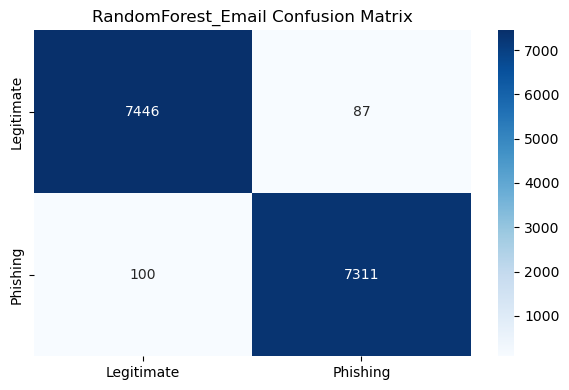

  Accuracy:  0.9875
  Precision: 0.9882
  Recall:    0.9865
  F1:        0.9874
  AUC:       0.9875
  Inference: 0.0211ms

Training XGBoost_Email...


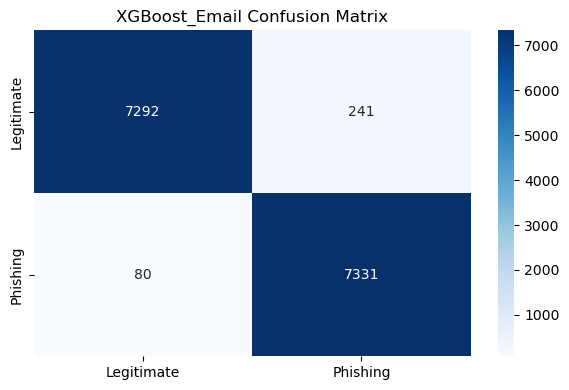

  Accuracy:  0.9785
  Precision: 0.9682
  Recall:    0.9892
  F1:        0.9786
  AUC:       0.9786
  Inference: 0.0007ms

Training DecisionTree_Email...


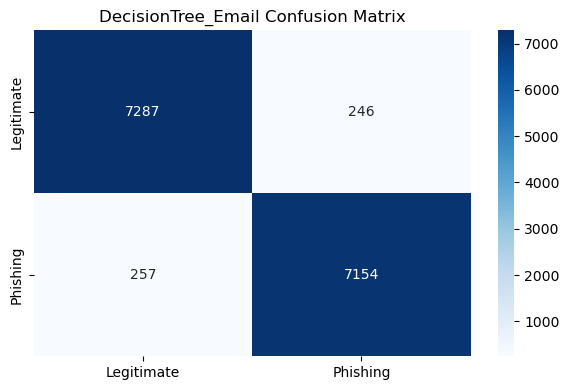

  Accuracy:  0.9663
  Precision: 0.9668
  Recall:    0.9653
  F1:        0.9660
  AUC:       0.9663
  Inference: 0.0004ms



In [4]:
email_models = {
    'RandomForest_Email': RandomForestClassifier(
                              n_estimators=100, random_state=489),
    'XGBoost_Email':      XGBClassifier(
                              random_state=489, eval_metric='logloss'),
    'DecisionTree_Email': DecisionTreeClassifier(random_state=489)
}

exp3_results = []
trained_email_models = {}

for name, model in email_models.items():
    print(f"Training {name}...")
    model.fit(X_train_tfidf, y_train_e)

    start = time.time()
    y_pred = model.predict(X_val_tfidf)
    inference_ms = (time.time() - start) / len(y_val_e) * 1000

    metrics = {
        'model':        name,
        'accuracy':     accuracy_score(y_val_e, y_pred),
        'precision':    precision_score(y_val_e, y_pred, zero_division=0),
        'recall':       recall_score(y_val_e, y_pred, zero_division=0),
        'f1':           f1_score(y_val_e, y_pred, zero_division=0),
        'auc':          roc_auc_score(y_val_e, y_pred),
        'inference_ms': round(inference_ms, 4)
    }
    exp3_results.append(metrics)
    trained_email_models[name] = model

    cm = confusion_matrix(y_val_e, y_pred)
    plot_confusion_matrix(cm, name)

    print(f"  Accuracy:  {metrics['accuracy']:.4f}")
    print(f"  Precision: {metrics['precision']:.4f}")
    print(f"  Recall:    {metrics['recall']:.4f}")
    print(f"  F1:        {metrics['f1']:.4f}")
    print(f"  AUC:       {metrics['auc']:.4f}")
    print(f"  Inference: {metrics['inference_ms']:.4f}ms\n")

In [5]:
exp3_df = pd.DataFrame(exp3_results)
exp3_df.to_csv('../results/experiment3_results.csv', index=False)

print("Experiment 3 results saved")
print(exp3_df[['model','accuracy','precision',
               'recall','f1','auc','inference_ms']])

Experiment 3 results saved
                model  accuracy  precision    recall        f1       auc  \
0  RandomForest_Email  0.987487   0.988240  0.986507  0.987373  0.987479   
1       XGBoost_Email  0.978520   0.968172  0.989205  0.978576  0.978606   
2  DecisionTree_Email  0.966341   0.966757  0.965322  0.966039  0.966333   

   inference_ms  
0        0.0211  
1        0.0007  
2        0.0004  


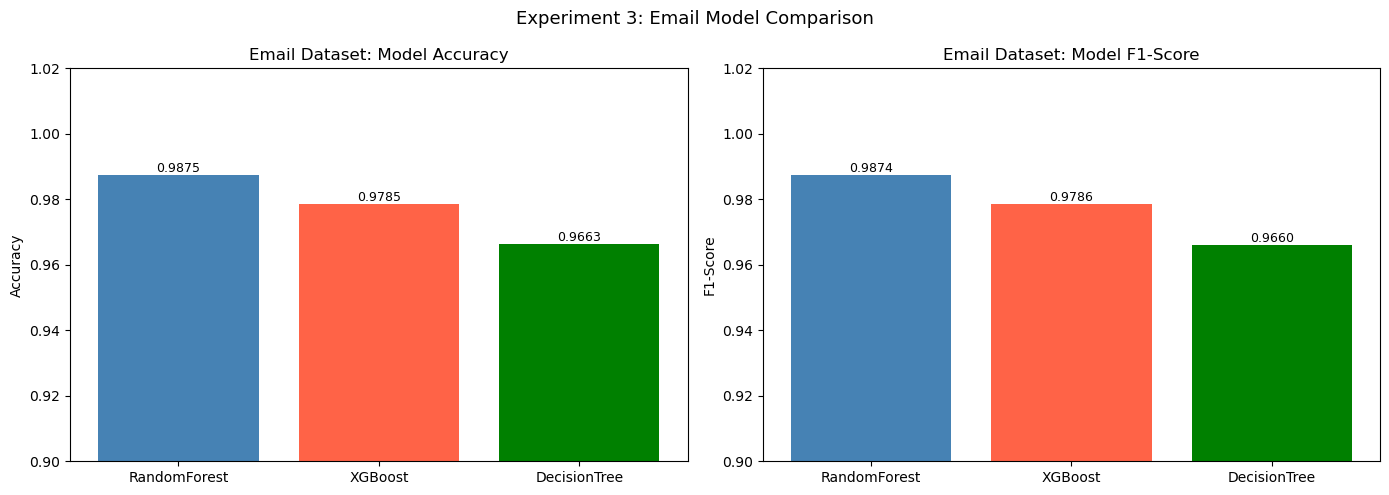

Chart saved


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

model_labels = ['RandomForest', 'XGBoost', 'DecisionTree']
colors = ['steelblue', 'tomato', 'green']

# Accuracy chart
bars = axes[0].bar(model_labels, exp3_df['accuracy'], color=colors)
axes[0].set_title('Email Dataset: Model Accuracy')
axes[0].set_ylabel('Accuracy')
axes[0].set_ylim(0.9, 1.02)
for bar, val in zip(bars, exp3_df['accuracy']):
    axes[0].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.001,
        f'{val:.4f}', ha='center', fontsize=9
    )

# F1 chart
bars2 = axes[1].bar(model_labels, exp3_df['f1'], color=colors)
axes[1].set_title('Email Dataset: Model F1-Score')
axes[1].set_ylabel('F1-Score')
axes[1].set_ylim(0.9, 1.02)
for bar, val in zip(bars2, exp3_df['f1']):
    axes[1].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.001,
        f'{val:.4f}', ha='center', fontsize=9
    )

plt.suptitle('Experiment 3: Email Model Comparison', fontsize=13)
plt.tight_layout()
plt.savefig('../results/figures/experiment3_model_comparison.png', dpi=150)
plt.show()
print("Chart saved")

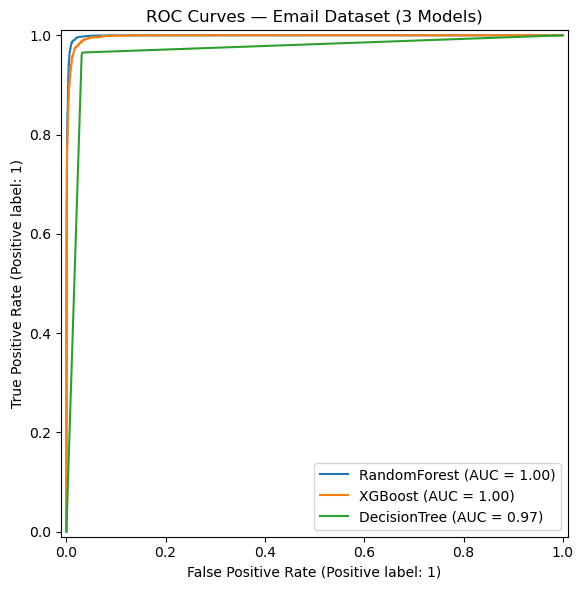

ROC curves saved


In [7]:
fig, ax = plt.subplots(figsize=(8, 6))

for name, model in trained_email_models.items():
    RocCurveDisplay.from_estimator(
        model, X_val_tfidf, y_val_e,
        ax=ax, name=name.replace('_Email', '')
    )

plt.title('ROC Curves — Email Dataset (3 Models)')
plt.tight_layout()
plt.savefig('../results/figures/roc_curves_email.png', dpi=150)
plt.show()
print("ROC curves saved")

In [8]:
best_email_name = exp3_df.loc[
    exp3_df['accuracy'].idxmax(), 'model'
]
print(f"Best email model: {best_email_name}")

best_email_model = trained_email_models[best_email_name]
y_test_pred = best_email_model.predict(X_test_tfidf)

print("\n=== FINAL EMAIL TEST SET RESULTS ===")
print(f"Model:     {best_email_name}")
print(f"Accuracy:  {accuracy_score(y_test_e, y_test_pred):.4f}")
print(f"Precision: {precision_score(y_test_e, y_test_pred):.4f}")
print(f"Recall:    {recall_score(y_test_e, y_test_pred):.4f}")
print(f"F1-Score:  {f1_score(y_test_e, y_test_pred):.4f}")

Best email model: RandomForest_Email

=== FINAL EMAIL TEST SET RESULTS ===
Model:     RandomForest_Email
Accuracy:  0.9874
Precision: 0.9892
Recall:    0.9853
F1-Score:  0.9872
